In [34]:
!pip install tensorflow


In [35]:
!pip install pandas

In [36]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [37]:
##import some basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [38]:
dataset = pd.read_csv('Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [39]:
##divide the dataset into independent and dependent features
##For independent features i will use X
X = dataset.iloc[:,3:13]
y = dataset.iloc[:,13]
X

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77
9997,709,France,Female,36,7,0.00,1,0,1,42085.58
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52


In [40]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [41]:
##Feature engineering ,  basically dataset is not that much clean, we need to divide categorical data
##drop_first = true basically reduced number of columns , like there were 3 columns france , germany , spain . it will only show 2 columns that are false , like in first row france
##was true , so france got removed from the column
geography = pd.get_dummies(X['Geography'],dtype=int,drop_first = True)
gender = pd.get_dummies(X['Gender'],dtype = int , drop_first = True)


In [42]:
#concatenate these variables with dataframes
X = X.drop(['Geography','Gender'],axis=1)
##axis = 1 means , we are dropping columns not row


In [43]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [44]:
pd.concat([X,geography,gender],axis=1)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1


In [45]:
#splitting the dataset into train and test set
from sklearn.model_selection import train_test_split

X_train , X_test ,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)


Feature scaling is used wherever there is distance based problem , or wherever optimizers , gradient descent is involved (scaling)


In [46]:
#feature scaling

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [47]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ...,  0.64259497,
        -1.03227043,  1.10643166],
       [-2.30455945,  0.30102557, -1.37744033, ...,  0.64259497,
         0.9687384 , -0.74866447],
       [-1.19119591, -0.94312892, -1.031415  , ...,  0.64259497,
        -1.03227043,  1.48533467],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ...,  0.64259497,
        -1.03227043,  1.41231994],
       [-0.62420521, -0.08179119,  1.39076231, ...,  0.64259497,
         0.9687384 ,  0.84432121],
       [-0.28401079,  0.87525072, -1.37744033, ...,  0.64259497,
        -1.03227043,  0.32472465]])

In [48]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  0.64259497,
         0.9687384 ,  1.61085707],
       [-1.31490297,  0.10961719, -1.031415  , ...,  0.64259497,
        -1.03227043,  0.49587037],
       [ 0.57162971,  0.30102557,  1.04473698, ...,  0.64259497,
         0.9687384 , -0.42478674],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ...,  0.64259497,
        -1.03227043,  0.71888467],
       [-0.00566991, -0.46460796, -0.33936434, ...,  0.64259497,
         0.9687384 , -1.54507805],
       [-0.79945688, -0.84742473,  1.04473698, ...,  0.64259497,
        -1.03227043,  1.61255917]])

In [49]:
X_train.shape

(8000, 8)

In [50]:
##Let's create ANN(Artificial neural network)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

##basically with the help of sequential , backpropagagtion and forward propagation is done
##dense layers bascically helps in creating neurons (hidden layers)
##activation functions then
##dropout layer - basically it reduces overfitting by removing the dead neurons from the network

In [51]:
#Let's initialize the ANN
Classifier = Sequential()

In [52]:
#Adding the input layer
Classifier.add(Dense(units=8,activation = 'relu')) # this 8 comes from the X_train.shape

In [53]:
#adding the first hidden layer
Classifier.add(Dense(units=5,activation='relu'))

In [54]:
#adding the second hidden layer
Classifier.add(Dense(units=4,activation='relu'))

In [55]:
#Adding the output layer
Classifier.add(Dense(units=1,activation='sigmoid'))

In [56]:
import tensorflow
opt = tensorflow.keras.optimizers.Adam(learning_rate=0.01)

In [57]:
Classifier.compile(optimizer=opt,loss='binary_crossentropy',metrics=['accuracy'])

By default adam optimizer uses learning rate of 0.01 , we don't need to manually enter learning rate . but still if we want we can write like this . Also we use adam optimizer because adam optimizer is the most optimal optimizer



In [58]:
#Early stopping
import tensorflow as tf
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)


A validation set is a subset of the training data used to evaluate model performance during training and tune hyperparameters, while the test set is used only for final evaluation.


In [59]:
model_history = Classifier.fit(X_train,y_train,validation_split = 0.33,batch_size=10,epochs=1000,callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7955 - loss: 0.4569 - val_accuracy: 0.8001 - val_loss: 0.4487
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8306 - loss: 0.3975 - val_accuracy: 0.8413 - val_loss: 0.3884
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8487 - loss: 0.3725 - val_accuracy: 0.8436 - val_loss: 0.3900
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8509 - loss: 0.3651 - val_accuracy: 0.8448 - val_loss: 0.3852
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8520 - loss: 0.3620 - val_accuracy: 0.8466 - val_loss: 0.3842
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8528 - loss: 0.3623 - val_accuracy: 0.8432 - val_loss: 0.3878
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8515 - loss: 0.3588 - val_accuracy: 0.8436 - val_loss: 0.3777
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8545 - loss: 0.3580 - 

In [60]:
model_history.history.keys()
#this command will not run if i interpted the epoch (if i didn't use early stopping)

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

Early stopping - when accuracy gets same for every epoch , or no significant change . model stops running more epochs

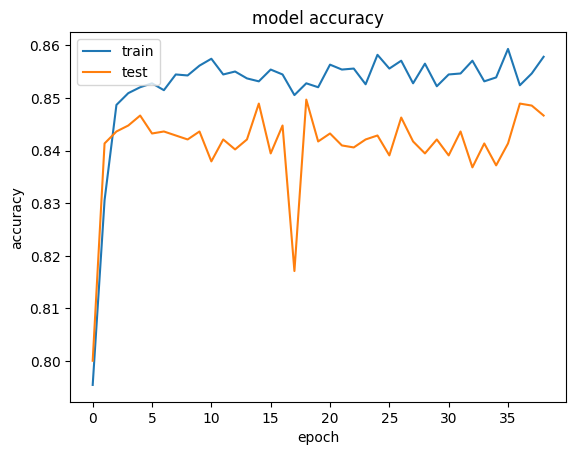

In [61]:
#summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

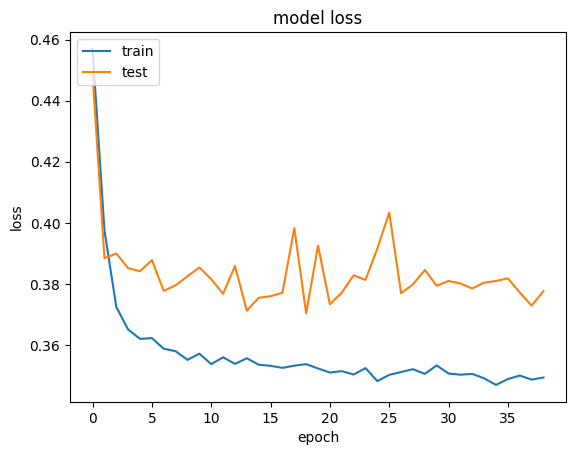

In [62]:
#summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

In [67]:
#Part 3 - Making the predictions and evaluating the model

#Predicting the Test set results
y_pred = Classifier.predict(X_test)
y_pred = (y_pred >= 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [68]:
#make the confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[1550,   45],
       [ 250,  155]])

In [69]:
#calculate the accuracy
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred,y_test)
score

0.8525

In [70]:
#get the weights
Classifier.get_weights()

[array([[ 0.10299353,  0.49994123, -0.18480548,  1.2660167 ,  0.06048081,
          0.18012148, -1.5320575 ,  0.2274792 ],
        [ 1.1000327 , -2.8157487 , -3.409858  , -1.7226343 , -0.629589  ,
          1.3466957 , -0.37191096, -1.4232891 ],
        [ 0.33865538,  0.40561146, -0.31994   , -0.12125867, -0.1461653 ,
         -0.16367112,  1.2476162 , -0.08797581],
        [-2.3305404 ,  0.8958274 , -0.33289093, -0.25073832,  0.7413463 ,
          0.34977743,  1.084842  , -0.52834404],
        [ 0.08170386, -1.6134179 , -0.49693108, -0.37096712,  2.787777  ,
         -0.30595803, -0.1751926 , -4.153898  ],
        [ 0.10739262,  0.7483841 , -0.7440076 ,  1.4429879 , -0.09748908,
         -0.19122829, -0.06257343,  0.09279518],
        [ 0.36932403,  0.17000864,  0.15717696,  0.9665484 , -0.03158823,
         -2.908909  ,  1.6545675 , -0.73011476],
        [-0.10745914,  0.20945999, -0.38540417,  1.6891735 ,  0.01875747,
          0.13419011, -0.22584982,  0.05739957]], dtype=float32),